In [17]:
import pandas as pd

df = pd.read_csv("SampleSuperstore.csv.zip.csv")

In [18]:
df.head()

,Ship Mode,Segment,Country,City,State,Postal Code,Region,Category,Sub-Category,Sales,Quantity,Discount,Profit
0,Second Class,Consumer,United States,Henderson,Kentucky,42420,South,Furniture,Bookcases,261.9600,2,0.00,41.9136
1,Second Class,Consumer,United States,Henderson,Kentucky,42420,South,Furniture,Chairs,731.9400,3,0.00,219.5820
2,Second Class,Corporate,United States,Los Angeles,California,90036,West,Office Supplies,Labels,14.6200,2,0.00,6.8714
3,Standard Class,Consumer,United States,Fort Lauderdale,Florida,33311,South,Furniture,Tables,957.5775,5,0.45,-383.0310
4,Standard Class,Consumer,United States,Fort Lauderdale,Florida,33311,South,Office Supplies,Storage,22.3680,2,0.20,2.5164


In [19]:
df.shape

(9994, 13)

In [20]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 13 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Ship Mode     9994 non-null   object 
 1   Segment       9994 non-null   object 
 2   Country       9994 non-null   object 
 3   City          9994 non-null   object 
 4   State         9994 non-null   object 
 5   Postal Code   9994 non-null   int64  
 6   Region        9994 non-null   object 
 7   Category      9994 non-null   object 
 8   Sub-Category  9994 non-null   object 
 9   Sales         9994 non-null   float64
 10  Quantity      9994 non-null   int64  
 11  Discount      9994 non-null   float64
 12  Profit        9994 non-null   float64
dtypes: float64(3), int64(2), object(8)
memory usage: 1015.1+ KB


In [21]:
df.describe()

,Postal Code,Sales,Quantity,Discount,Profit
count,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000
mean,55190.379428,229.858001,3.789574,0.156203,28.656896
std,32063.693350,623.245101,2.225110,0.206452,234.260108
min,1040.000000,0.444000,1.000000,0.000000,-6599.978000
25%,23223.000000,17.280000,2.000000,0.000000,1.728750
50%,56430.500000,54.490000,3.000000,0.200000,8.666500
75%,90008.000000,209.940000,5.000000,0.200000,29.364000
max,99301.000000,22638.480000,14.000000,0.800000,8399.976000


In [22]:
df.tail()

,Ship Mode,Segment,Country,City,State,Postal Code,Region,Category,Sub-Category,Sales,Quantity,Discount,Profit
9989,Second Class,Consumer,United States,Miami,Florida,33180,South,Furniture,Furnishings,25.248,3,0.2,4.1028
9990,Standard Class,Consumer,United States,Costa Mesa,California,92627,West,Furniture,Furnishings,91.960,2,0.0,15.6332
9991,Standard Class,Consumer,United States,Costa Mesa,California,92627,West,Technology,Phones,258.576,2,0.2,19.3932
9992,Standard Class,Consumer,United States,Costa Mesa,California,92627,West,Office Supplies,Paper,29.600,4,0.0,13.3200
9993,Second Class,Consumer,United States,Westminster,California,92683,West,Office Supplies,Appliances,243.160,2,0.0,72.9480


In [23]:
df.sample(5)

,Ship Mode,Segment,Country,City,State,Postal Code,Region,Category,Sub-Category,Sales,Quantity,Discount,Profit
6725,Standard Class,Consumer,United States,Seattle,Washington,98103,West,Office Supplies,Labels,11.070,3,0.0,5.2029
53,Standard Class,Corporate,United States,New York City,New York,10024,East,Office Supplies,Fasteners,15.260,7,0.0,6.2566
6029,First Class,Consumer,United States,Los Angeles,California,90049,West,Office Supplies,Art,9.840,3,0.0,2.8536
7787,First Class,Consumer,United States,Chicago,Illinois,60653,Central,Office Supplies,Fasteners,7.896,3,0.2,2.4675
4118,Standard Class,Consumer,United States,Los Angeles,California,90036,West,Office Supplies,Storage,454.860,7,0.0,54.5832


In [24]:
df.columns

Index(['Ship Mode', 'Segment', 'Country', 'City', 'State', 'Postal Code',
       'Region', 'Category', 'Sub-Category', 'Sales', 'Quantity', 'Discount',
       'Profit'],
      dtype='object')

In [25]:
df.dtypes

,0
Ship Mode,object
Segment,object
Country,object
City,object
State,object
Postal Code,int64
Region,object
Category,object
Sub-Category,object
Sales,float64


In [26]:
df.isnull().sum()

,0
Ship Mode,0
Segment,0
Country,0
City,0
State,0
Postal Code,0
Region,0
Category,0
Sub-Category,0
Sales,0


In [27]:
df["Category"].unique()

array(['Furniture', 'Office Supplies', 'Technology'], dtype=object)

In [28]:
df.nunique()

,0
Ship Mode,4
Segment,3
Country,1
City,531
State,49
Postal Code,631
Region,4
Category,3
Sub-Category,17
Sales,5825


In [29]:
df.duplicated().sum()

np.int64(17)

In [30]:
df = df.drop_duplicates()

In [64]:
df.duplicated().sum()

np.int64(0)

In [31]:
df.columns = df.columns.str.strip()

In [32]:
# SQL
!pip install pandasql

In [33]:
from pandasql import sqldf

In [34]:
pysqldf = lambda q: sqldf(q, globals())

In [35]:
 #SQL QUERIES
 # TOTAL SALES

 pysqldf("SELECT SUM(Sales) AS Total_Sales FROM df")

,Total_Sales
0,2.296196e+06


In [36]:
#TOP 5 PRODUCTS
pysqldf("""
SELECT [Sub-Category], SUM(Sales) AS Total
FROM df
GROUP BY [Sub-Category]
ORDER BY Total DESC
LIMIT 5
""")

,Sub-Category,Total
0,Phones,330007.054
1,Chairs,327777.761
2,Storage,223843.608
3,Tables,206965.532
4,Binders,203409.169


In [37]:
#Sales by Category
pysqldf("""
SELECT Category, SUM(Sales) AS Total
FROM df
GROUP BY Category
""")

,Category,Total
0,Furniture,741306.3133
1,Office Supplies,718735.2440
2,Technology,836154.0330


In [38]:
# Discount vs Profit Analysis
pysqldf("""
SELECT Discount, SUM(Profit) AS Total_Profit
FROM df
GROUP BY Discount
ORDER BY Discount
""")

,Discount,Total_Profit
0,0.00,320844.4073
1,0.10,9029.1770
2,0.15,1418.9915
3,0.20,90306.6070
4,0.30,-10357.2186
5,0.32,-2391.1377
6,0.40,-23057.0504
7,0.45,-2493.1111
8,0.50,-20506.4281
9,0.60,-5944.6552


In [39]:
# Profit Margin by Category
pysqldf("""
SELECT Category,
SUM(Profit) AS Total_Profit,
SUM(Sales) AS Total_Sales,
(SUM(Profit)*100.0 / SUM(Sales)) AS Profit_Margin_Percentage
FROM df
GROUP BY Category
ORDER BY Profit_Margin_Percentage DESC
""")

,Category,Total_Profit,Total_Sales,Profit_Margin_Percentage
0,Technology,145454.9481,836154.0330,17.395712
1,Office Supplies,122364.6608,718735.2440,17.024998
2,Furniture,18421.8137,741306.3133,2.485047


In [40]:
#BUSINESS ANALYSIS
#Sales by Region
pysqldf("""
SELECT Region, SUM(Sales) AS Total_Sales
FROM df
GROUP BY Region
ORDER BY Total_Sales DESC
""")

,Region,Total_Sales
0,West,725255.6365
1,East,678435.1960
2,Central,500782.8528
3,South,391721.9050


In [41]:
#Profit by Category
pysqldf("""
SELECT Category, SUM(Profit) AS Total_Profit
FROM df
GROUP BY Category
ORDER BY Total_Profit DESC
""")

,Category,Total_Profit
0,Technology,145454.9481
1,Office Supplies,122364.6608
2,Furniture,18421.8137


In [42]:
#Loss-making categories
pysqldf("""
SELECT [Sub-Category], SUM(Profit) AS Total_Profit
FROM df
GROUP BY [Sub-Category]
HAVING Total_Profit < 0
""")

,Sub-Category,Total_Profit
0,Bookcases,-3472.5560
1,Supplies,-1189.0995
2,Tables,-17725.4811


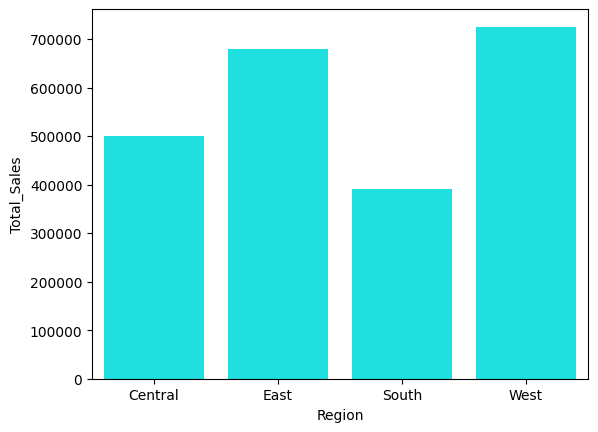

In [55]:
#VISUALIZATION
#Sales by Region
import seaborn as sns
import matplotlib.pyplot as plt

region_sales = pysqldf("""
SELECT Region, SUM(Sales) AS Total_Sales
FROM df
GROUP BY Region
""")

sns.barplot(x="Region", y="Total_Sales", data=region_sales,color='cyan')
plt.show()

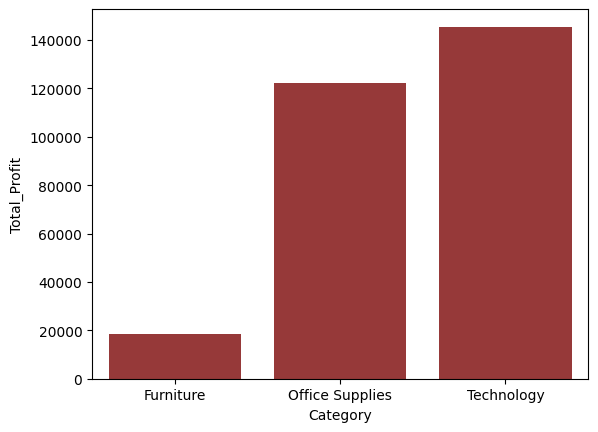

In [62]:
#Profit by Category
category_profit = pysqldf("""
SELECT Category, SUM(Profit) AS Total_Profit
FROM df
GROUP BY Category
""")

sns.barplot(x="Category", y="Total_Profit", data=category_profit,color='brown')
plt.show()

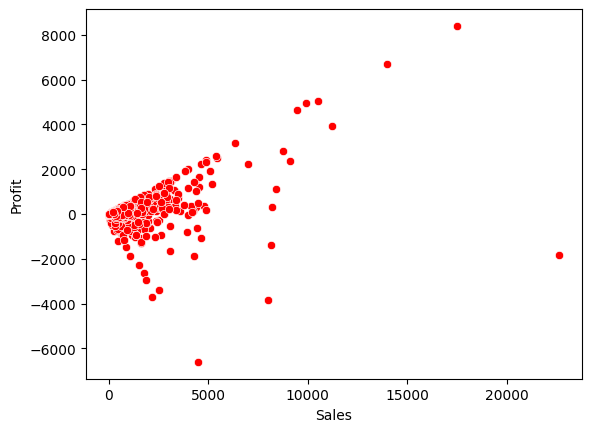

In [51]:
#Sales vs Profit
sns.scatterplot(x="Sales", y="Profit", data=df,color='red')
plt.show()

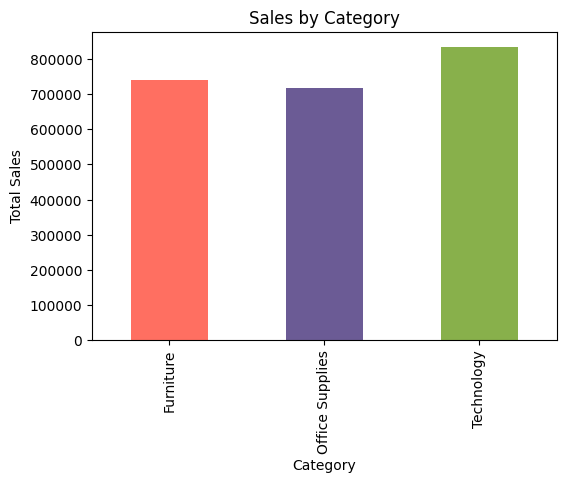

In [63]:
# Sales by Category Chart

plt.figure(figsize=(6,4))

df.groupby('Category')['Sales'].sum().plot(
    kind='bar',
    color=['#FF6F61', '#6B5B95', '#88B04B']
)

plt.title("Sales by Category")
plt.xlabel("Category")
plt.ylabel("Total Sales")

plt.show()